 ## OTT Customer Churn & Retention Analysis

In [ ]:
# Churn Analysis and Customer Intelligence

### Libraries and Imports

In [96]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


## 1. import database/data

In [186]:
# Connect to SQLite Database
conn = sqlite3.connect('customer_churn.db')

sql_query="""
          SELECT name
          FROM sqlite_master
          WHERE type='table'

"""
# read SQL query in pandas
tables=pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn) # Read table into dataframe
    globals() [f"df_{table_name}"]=df                  # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")
#close connection
conn.close()


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [99]:
#Print table name and  column name
conn=sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\n Table Name:{table_name}")
    #Get column information
    columns_query= f"PRAGMA table_info ({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("columns:")
    print(columns['name'].tolist())
#close connection
conn.close()



 Table Name:db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name:db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name:db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 2. Data Cleaning

In [101]:
# Customer Table
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [102]:
df_db_customer.tail()


,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [103]:
df_db_customer.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [104]:
# a.rename col- name
# b.drop columns- interest and pincode
# c.change datatype- dob
# d.data standardization - gender
# e. fix missing values - country

#### a. Rename Col

In [189]:
df_db_customer.rename(columns= {'name':'customer_name'}, inplace=True)
df_db_customer.head()


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [193]:
# drop interest and pincode
# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)
df_db_customer.drop(columns=['interests','pincode'], inplace=True) # Using Col name
 

KeyError: "['interests', 'pincode'] not found in axis"

In [194]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


#### c. Change Datatype

In [108]:
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

#### d. Data Standardization

In [195]:
# d.data standardization - gender
#df_db_customer['gender'].unique
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

#### e. Fix Missing values

In [197]:
# e. fix missing values - country
#df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07 00:00:00
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01 00:00:00


In [198]:
#Country and state - unique value pair
# Creating state → country map from non-null rows
state_country_mapping= df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
# Fill the missing Country using State
df_db_customer['country']= df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [199]:
df_db_customer[df_db_customer['country'].isna()] # No Null value in country Col

,customerid,customer_name,country,state,gender,dob


In [114]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [115]:
df_db_subscription.head() # Subscription Table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [116]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [200]:
# change dtype- subscription_start_date, cancellation_date, renewal_date
date_col=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]= df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [201]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [205]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [203]:
# drop columns

df_db_support.drop(columns=['col_1','comment'], inplace= True)

KeyError: "['col_1', 'comment'] not found in axis"

In [206]:
# change data type to date - complaint_date
df_db_support['complaint_date']= df_db_support['complaint_date'].apply(pd.to_datetime)
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


## 3.FEATURE ENGINEERING & ANALYSIS

#### Create a new Col

In [207]:
# create a new column using an existing column - churn flag
df_db_subscription['churn_flag']= np.where(df_db_subscription['cancellation_date'].notna(), 1,0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [124]:
# to merge or join tables/ dataframes
# first fix support table duplicates then merge
df= (df_db_subscription
 .merge(df_db_customer, on='customerid', how='left')
 .merge(df_db_support, on='customerid', how='left'))


In [125]:
df_db_subscription.shape

(21, 12)

In [126]:
df.shape

(23, 20)

In [209]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 21
df_db_customer unique value: 21
df_db_support unique value: 7
df_db_support all value: 9


In [132]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [133]:
df_db_support['complaint_count']= df_db_support.groupby('customerid')['customerid'].transform('count')

In [135]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [136]:
df_db_support['customerid'].size

7

In [137]:
# merge df - to merge or join tables/ dataframes
df= (df_db_subscription
 .merge(df_db_customer, on='customerid', how='left')
 .merge(df_db_support, on='customerid', how='left'))

In [138]:
df.shape

(21, 21)

#### Export Dataframe

In [139]:
# Export dataframe to csv file
df.to_csv('exported_churn_data.csv', index= False)

## Data Analysis

In [141]:
#1. Churn Rate

In [142]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [143]:
churn_rate= df['churn_flag'].mean()*100
print("Churn Rate= ", round(churn_rate, 2), "%")

Churn Rate=  28.57 %


In [144]:
# 2. Retention Rate
retention_rate= 100 - churn_rate
print("Rentention Rate=", round(retention_rate, 2), "%")

Rentention Rate= 71.43 %


In [145]:
#3. Churn by plan type
#df.head(2)
churn_by_plan= (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [146]:
#4 a. Churn by state + sum(revenue) and count of users
churn_by_state = (
    df[df['churn_flag'] == 1]
    .groupby('state')
    .agg(
        churned_customers=('customerid', 'count'),
        revenue_lost=('monthly_charges', 'sum')
    )
    .sort_values(by='revenue_lost', ascending=False)
    .reset_index()
)

print(churn_by_state)

       state  churned_customers  revenue_lost
0  Meghalaya                  2         21.98
1  Karnataka                  2         20.98
2  Telangana                  1         16.99
3      Delhi                  1         13.99


In [147]:
# 4  b. Churn by subscription type + sum(revenue) and count of users
churn_by_plan = (
    df[df['churn_flag'] == 1]
    .groupby('plan_type')
    .agg(
        churned_customers=('customerid', 'count'),
        revenue_lost=('monthly_charges', 'sum')
    )
    .sort_values(by='revenue_lost', ascending=False)
    .reset_index()
)

print(churn_by_plan)

  plan_type  churned_customers  revenue_lost
0     Basic                  3         38.97
1  Standard                  2         21.98
2   Premium                  1         12.99


In [148]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count']


In [149]:
#5. ARPU-- Average Revenue Per User
arpu= df['monthly_charges'].mean()
print("ARPU=", round(arpu, 2))

ARPU= 18.85


In [150]:
#6. Average revenue lost per churned customer
churn_by_state['avg_revenue_per_churned_customer'] = (
    churn_by_state['revenue_lost'] /
    churn_by_state['churned_customers']
).round(2)

print(churn_by_state)

       state  churned_customers  revenue_lost  \
0  Meghalaya                  2         21.98   
1  Karnataka                  2         20.98   
2  Telangana                  1         16.99   
3      Delhi                  1         13.99   

   avg_revenue_per_churned_customer  
0                             10.99  
1                             10.49  
2                             16.99  
3                             13.99  


In [151]:
#7. Total Revenue
total_revenue = arpu * len(df)
print("Total revenue:", total_revenue)

Total revenue: 395.78999999999996


In [153]:
#8. CLTV- Customer lifetime value
cltv_lost = df.loc[df['churn_flag'] == 1, 'cltv'].sum()

print("Estimated CLTV Lost (Rs 'k') =", round(cltv_lost, 2))


Estimated CLTV Lost (Rs 'k') = 2047


In [155]:
#9. Average Customer Tenure
# Count of days user has used our service : cancellation date else current date
today = pd.Timestamp.today()
df['tenure_days']= np.where(
        df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today -  df['subscription_start_date']).dt.days
    
)
avg_tenure= df['tenure_days'].mean()
print("Average Tenure (Days)=", round(avg_tenure),0)


Average Tenure (Days)= 1526 0


In [156]:
#10.  Revenue at Risk - revenue lost from churned users
revenue_at_risk= df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'k')=", revenue_at_risk)

Revenue at Risk (Rs 'k')= 73.94


In [157]:
#11. Revenue lost percentage
total_revenue= df['monthly_charges'].sum()
revenue_at_risk= df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
revenue_loss_pct= (revenue_at_risk / total_revenue) * 100
print(f"Revenue Loss % = {revenue_loss_pct:.2f}%")

Revenue Loss % = 18.68%


In [158]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1991.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1376.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2666.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,419.0


In [159]:
#12. Escalation Rate
escalation_rate= (df['escalations']=='Y').mean()*100
print("Escalation Rate=", round(escalation_rate,2), "%")

Escalation Rate= 19.05 %


In [160]:
#13. Average Complaint per User
avg_complaints= df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaint per user=", round(avg_complaints, 2))

Avg Complaint per user= 0.43


In [161]:
#14. monthly vs annual churn
contract_churn = (
    df.groupby('contract_type')['churn_flag']
      .mean()
      .mul(100)
      .round(1)
      .reset_index(name='churn_rate_pct')
)

print(contract_churn)

  contract_type  churn_rate_pct
0        Annual             8.3
1       Monthly            55.6


In [162]:
#15. Correlation escalation vs churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df= df[['escalations','churn_flag']].dropna()  
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn = ",round(correlation, 2))

Correlation between escalation vs churn =  0.77


In [164]:
#16. Create a column  from existing column - churn risk
conditions= [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >=70)
]
choices= ['low', 'Medium', 'High']

df['churn_risk'] = np.select (conditions, choices, default='unknown')


In [165]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,Medium,62
17,low,27
18,High,99
19,low,7
20,low,47


## 4. Visualization using Matplotlib

In [167]:
df_visual=df.copy()

In [168]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

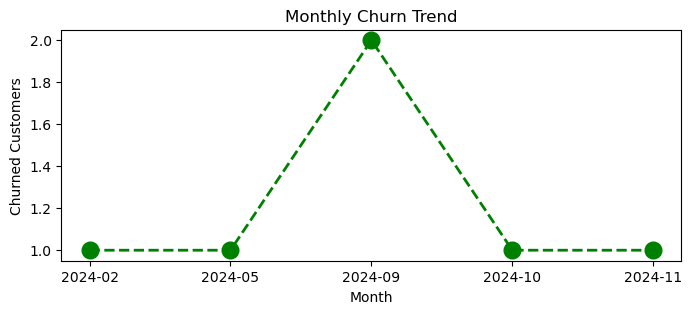

In [169]:
#4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month']= df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()


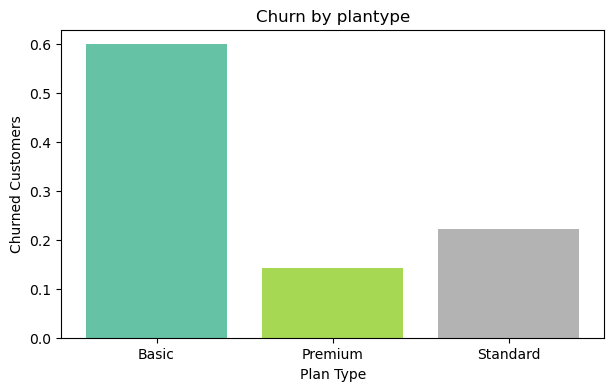

In [170]:
#4.2 Churn Rate by plan
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
colors= plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.title('Churn by plantype')
plt.xlabel('Plan Type')
plt.ylabel('Churned Customers')
plt.show()

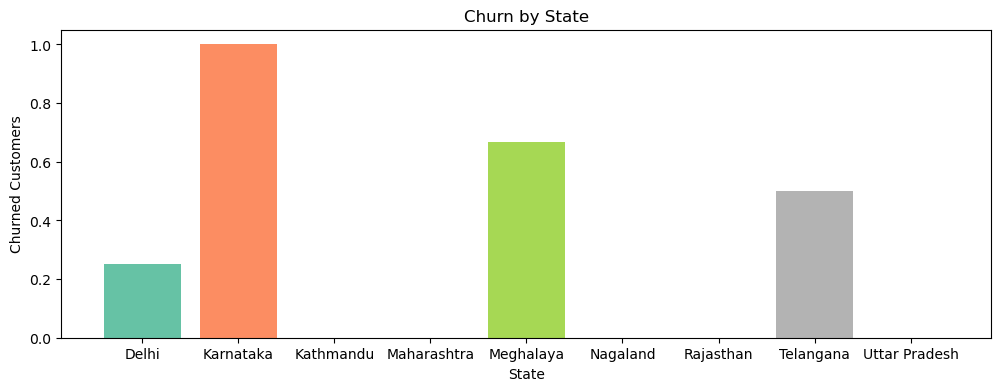

In [171]:
#4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
colors= plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.title('Churn by State')
plt.xlabel('State')
plt.ylabel('Churned Customers')
plt.show()


## Visualization using seaborn

In [ ]:
# HeatMap (Correlation Matrix)

In [173]:
# encoding - convert str to numeric so that we can find correlation between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [174]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,High
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,High


In [175]:
# remove warnings
import warnings
warnings.filterwarnings('ignore')

In [176]:
# Correct Method Of encoding - as numbers are assigned based on priority
df_encoded= df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations','churn_risk']]

order_mappings= {
    'plan_type': ['Basic','Standard','Premium'], 
    'contract_type':['Monthly', 'Annual'],
    'churn_risk':['low','Medium', 'High'] }
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered= True).codes

In [177]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


In [178]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,High
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,High


<Axes: >

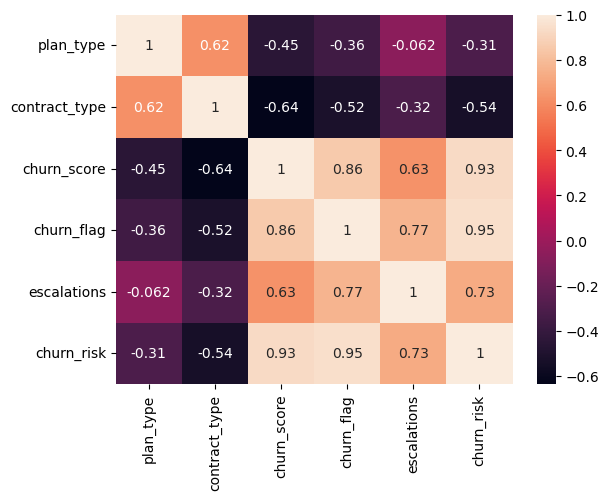

In [179]:
# HeatMap Correlation Matrix
sns.heatmap(df_encoded.corr(), annot=True)

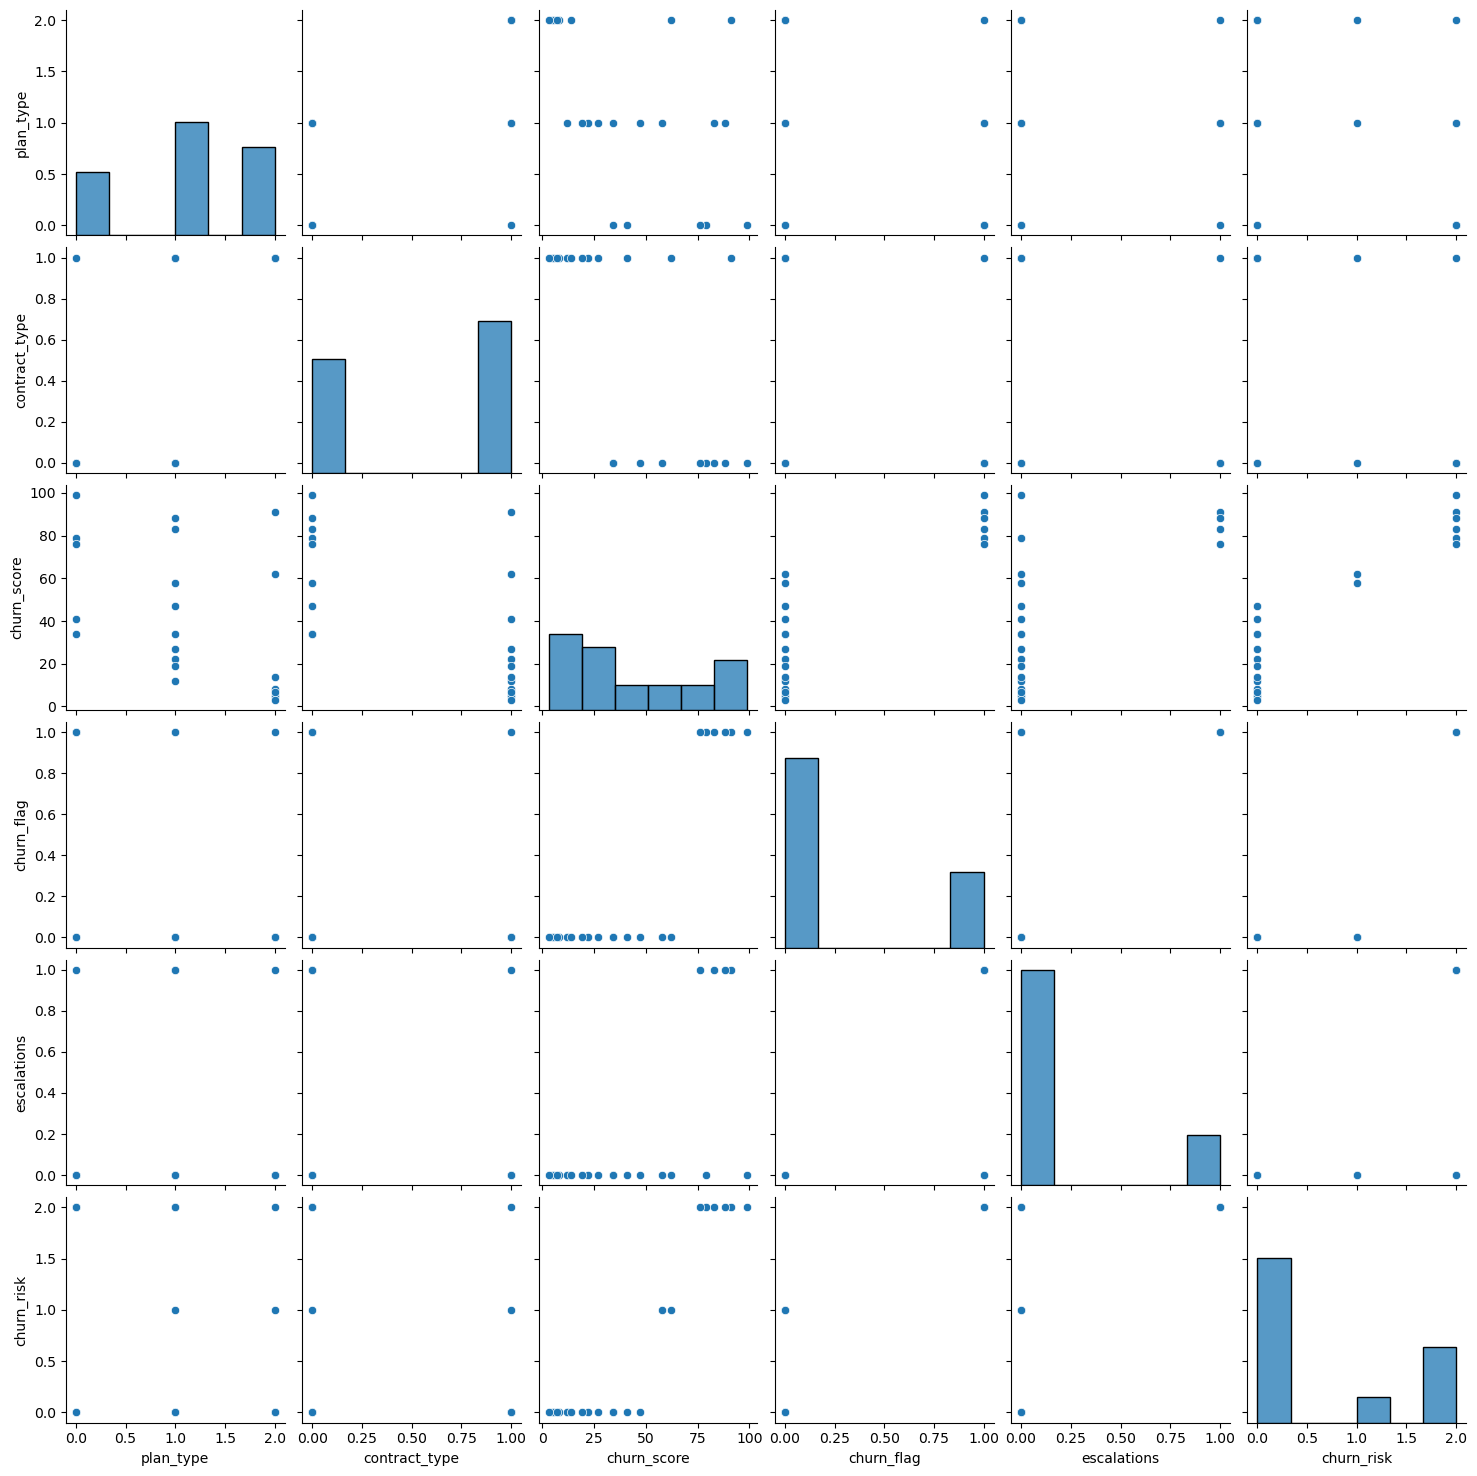

In [180]:
# pairplot - plot pair wise relationship in a database
sns.pairplot(df_encoded)

In [181]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

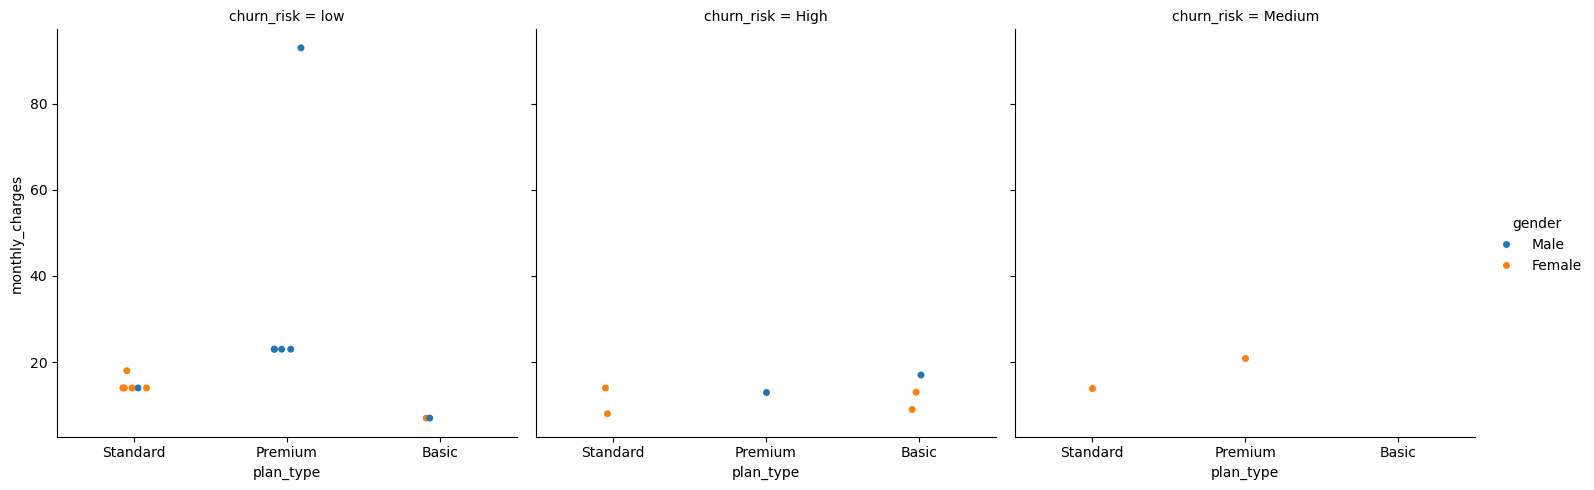

In [210]:
# catplot/Facegridplot - multi - dimensonal comparison
sns.catplot(data=df_visual,
               x='plan_type',
               y='monthly_charges',
               hue='gender',
               col='churn_risk')

## Pivot Table

In [183]:
# pivot table
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [185]:
# Pivot table using multiple cols and agg type
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc = {'monthly_charges': 'sum',
               'customerid': 'nunique',
               'churn_flag': 'mean'
              }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91
